In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from kerastuner.tuners import RandomSearch

/tmp/ipython-input-2172606282.py:7: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import RandomSearch


In [13]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.7 MB/s eta 0:00:00


In [2]:
def load_data(path):
    print(f"Loading data from {path}")
    data = pd.read_csv(path)
    data = data.sort_values("ts").reset_index(drop=True)
    data.drop(columns=["ts"], inplace=True)
    print(data.head())
    return data

In [3]:
def create_sequences(X, y, seq_length=24):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        # Take a sliding window of 24 hours of features
        X_seq.append(X[i:i+seq_length])
        # Predict the glucose *after* those 24 hours
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

In [4]:
def train_model(df):
  # split features and target
  Y = df["value"]
  X = df.drop(columns=["value"])

  # create sequences to feed to model
  X_seqs, y_seqs = create_sequences(X, Y)

  # convert because it hates my booleans
  X_seqs = X_seqs.astype("float32")
  y_seqs = y_seqs.astype("float32")

  # split training/testing data
  X_train, X_temp, y_train, y_temp = train_test_split(
      X_seqs, y_seqs, test_size=0.2, shuffle=False
  )

  X_val, X_test, y_val, y_test = train_test_split(
      X_temp, y_temp, test_size=0.5, shuffle=False
  )

  # build the model
  seq_length = 24

  model = models.Sequential([
      layers.Input(shape=(seq_length, X_train.shape[2])),
      layers.SimpleRNN(64, return_sequences=True),
      layers.SimpleRNN(16),
      layers.Dense(1)
  ])

  model.compile(
      optimizer="adam",
      loss="mse",
      metrics=["mae"]
  )

  history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]
  )

  return model, X_test, y_test, X_val, y_val, history

Loading data from 2301.csv
   intensity     value   carbs_g    prot_g     fat_g  bolus_dose  basal_dose  \
0   0.221424 -0.242057 -0.282536 -0.281262 -0.294808   -0.386919    4.689616   
1  -0.897371 -0.242057 -0.282536 -0.281262 -0.294808   -0.386919    4.460799   
2  -0.897371  3.055902 -0.282536 -0.281262 -0.294808   -0.386919    1.394359   
3  -0.897371  3.085546 -0.282536 -0.281262 -0.294808   -0.386919    4.467659   
4   0.221424  2.526005 -0.282536 -0.281262 -0.294808   -0.386919    2.911314   

   is_asleep  time_of_day_Afternoon  time_of_day_Evening  time_of_day_Morning  \
0      False                  False                False                False   
1      False                  False                False                False   
2      False                  False                False                False   
3      False                  False                False                False   
4      False                  False                False                False   

   ti

/tmp/ipython-input-116582826.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


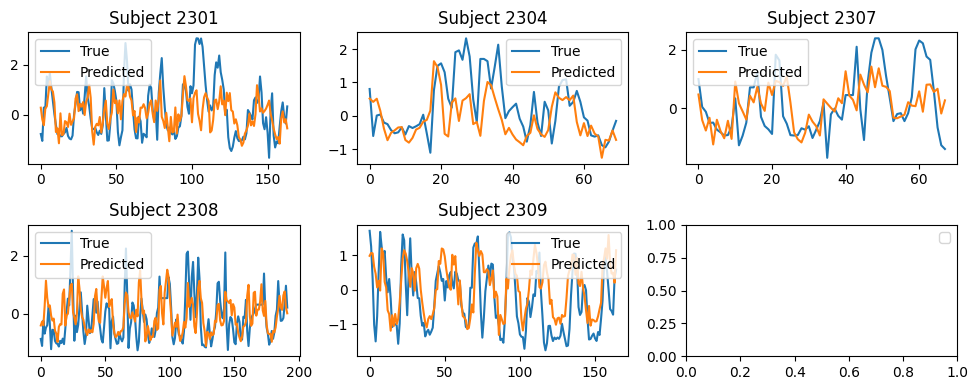

In [8]:
ids = [2301, 2304, 2307, 2308, 2309]

fig, axs = plt.subplots(2, 3, figsize=(10, 4))

for i, subject_id in enumerate(ids):
  path = f"{subject_id}.csv"
  df = load_data(path)

  model, X_test, y_test, X_val, y_val, history = train_model(df)

  y_pred = model.predict(X_val)

  ax = axs[i//3, i%3]

  ax.plot(y_val, label="True")
  ax.plot(y_pred, label="Predicted")
  ax.set_title(f"Subject {ids[i]}")
  ax.legend()

plt.tight_layout()
plt.legend()
plt.show()

In [5]:
subject_id = 2301
path = f"{subject_id}.csv"

df = load_data(path)

model, X_test, y_test, X_val, y_val, history = train_model(df)
# score = test_model(model, X_test, y_test)

# print(score)

Loading data from 2301.csv
   intensity     value   carbs_g    prot_g     fat_g  bolus_dose  basal_dose  \
0   0.221424 -0.242057 -0.282536 -0.281262 -0.294808   -0.386919    4.689616   
1  -0.897371 -0.242057 -0.282536 -0.281262 -0.294808   -0.386919    4.460799   
2  -0.897371  3.055902 -0.282536 -0.281262 -0.294808   -0.386919    1.394359   
3  -0.897371  3.085546 -0.282536 -0.281262 -0.294808   -0.386919    4.467659   
4   0.221424  2.526005 -0.282536 -0.281262 -0.294808   -0.386919    2.911314   

   is_asleep  time_of_day_Afternoon  time_of_day_Evening  time_of_day_Morning  \
0      False                  False                False                False   
1      False                  False                False                False   
2      False                  False                False                False   
3      False                  False                False                False   
4      False                  False                False                False   

   ti

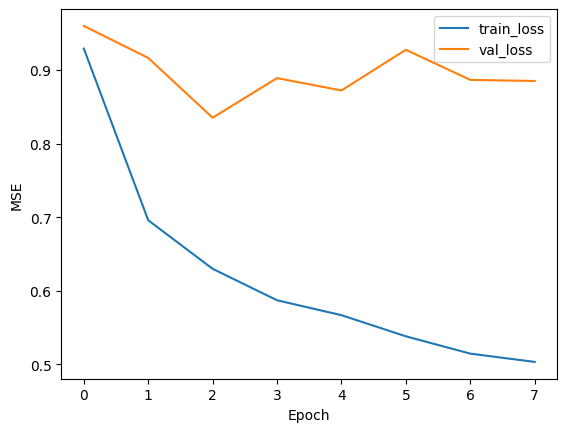

In [6]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [7]:
y_true = y_val
y_pred = model.predict(X_val)

plt.plot(y_val, label="True")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()

NameError: name 'y_val' is not defined

In [4]:
subject_id = 2301
path = f"{subject_id}.csv"

df = load_data(path)

Loading data from 2301.csv
   intensity     value   carbs_g    prot_g     fat_g  bolus_dose  basal_dose  \
0   0.221424 -0.242057 -0.282536 -0.281262 -0.294808   -0.386919    4.689616   
1  -0.897371 -0.242057 -0.282536 -0.281262 -0.294808   -0.386919    4.460799   
2  -0.897371  3.055902 -0.282536 -0.281262 -0.294808   -0.386919    1.394359   
3  -0.897371  3.085546 -0.282536 -0.281262 -0.294808   -0.386919    4.467659   
4   0.221424  2.526005 -0.282536 -0.281262 -0.294808   -0.386919    2.911314   

   is_asleep  time_of_day_Afternoon  time_of_day_Evening  time_of_day_Morning  \
0      False                  False                False                False   
1      False                  False                False                False   
2      False                  False                False                False   
3      False                  False                False                False   
4      False                  False                False                False   

   ti

In [5]:
# I'm evil for using ChatGPT I know but this is due in less than 12 hours
def create_sequences(X, y, seq_length=24):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        # Take a sliding window of 24 hours of features
        X_seq.append(X[i:i+seq_length])
        # Predict the glucose *after* those 24 hours
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

# Splitting features and target
Y = df["value"]
X = df.drop(columns=["value"])

X_seqs, y_seqs = create_sequences(X, Y)

X_seqs = X_seqs.astype("float32")
y_seqs = y_seqs.astype("float32")

print(X_seqs.shape)

(1639, 24, 11)


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_seqs, y_seqs, test_size=0.2, shuffle=False
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, shuffle=False
)

In [7]:
seq_length = 24

model = models.Sequential([
    layers.Input(shape=(seq_length, X_train.shape[2])),
    layers.SimpleRNN(32, return_sequences=True),
    layers.SimpleRNN(16),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 24, 32)         │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 16)             │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,209 (8.63 KB)

 Trainable params: 2,209 (8.63 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
print(X_seqs.dtype)

float32


In [8]:
# train model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/40
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 1.0378 - mae: 0.8036 - val_loss: 0.9932 - val_mae: 0.7538
Epoch 2/40
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.7676 - mae: 0.6716 - val_loss: 0.8725 - val_mae: 0.6914
Epoch 3/40
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.6160 - mae: 0.5898 - val_loss: 0.9142 - val_mae: 0.6957
Epoch 4/40
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.6271 - mae: 0.6006 - val_loss: 0.8885 - val_mae: 0.6799
Epoch 5/40
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.5504 - mae: 0.5680 - val_loss: 0.8739 - val_mae: 0.6720
Epoch 6/40
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.5778 - mae: 0.5700 - val_loss: 0.9060 - val_mae: 0.6755
Epoch 7/40
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.5240 - mae: 0.5434 - val_loss: 0.8735 - val_mae: 0.6665


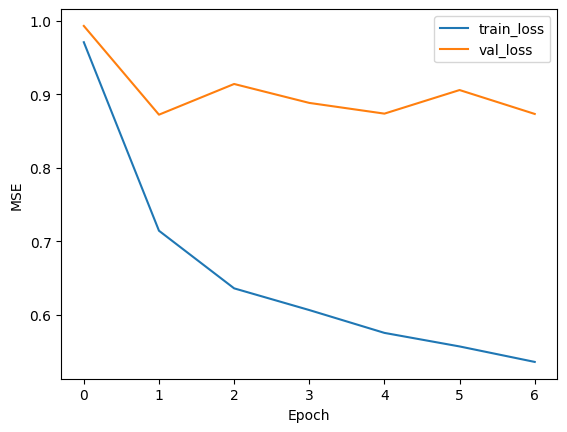

In [9]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step


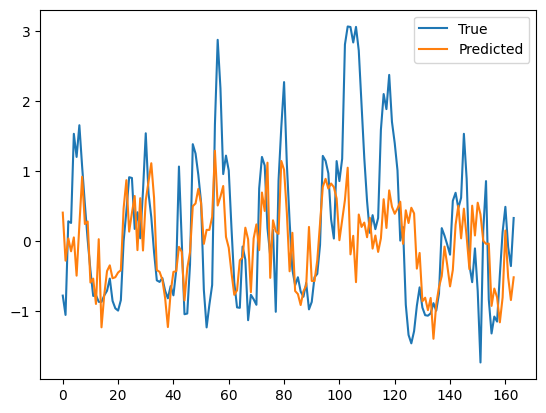

In [10]:
y_true = y_val
y_pred = model.predict(X_val)

plt.plot(y_val, label="True")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()

In [15]:
# optimize
def build_model(hp):
    seq_len = hp.Choice("seq_length", [24, 36, 48])
    units1 = hp.Choice("units_layer1", [32, 64])
    units2 = hp.Choice("units_layer2", [16, 32])
    dropout = hp.Float("dropout", 0.0, 0.3, step=0.1)
    lr = hp.Choice("learning_rate", [1e-3, 5e-4])

    model = models.Sequential([
        layers.Input(shape=(seq_len, X_train.shape[2])),
        layers.SimpleRNN(units1, return_sequences=True),
        layers.Dropout(dropout),
        layers.SimpleRNN(units2),
        layers.Dense(1)
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='mse',
                  metrics=['mae'])
    return model

tuner = RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=20,
    executions_per_trial=1,
    directory="rnn_tuning",
    project_name="glucose_rnn"
)

tuner.search(X_train, y_train, validation_data=(X_val, y_val), epochs=40, batch_size=32)

Trial 20 Complete [00h 00m 31s]
val_loss: 0.9190766215324402

Best val_loss So Far: 0.7835501432418823
Total elapsed time: 00h 10m 38s


In [16]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Example: access individual hyperparameters
seq_len = best_hps.get("seq_length")
units1 = best_hps.get("units_layer1")
units2 = best_hps.get("units_layer2")
dropout = best_hps.get("dropout")
lr = best_hps.get("learning_rate")

print("Best hyperparameters:")
print(f"Sequence length: {seq_len}")
print(f"Layer1 units: {units1}")
print(f"Layer2 units: {units2}")
print(f"Dropout: {dropout}")
print(f"Learning rate: {lr}")

Best hyperparameters:
Sequence length: 24
Layer1 units: 64
Layer2 units: 16
Dropout: 0.0
Learning rate: 0.0005
